In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("updated_startup_metric.csv")
df.head()

,month,mrr,active_users,cac,churn_rate,marketing_spend,burn_rate,rolling_avg,mrr_growth_rate,burn_ratio,net_growth
0,4,741000,741,1200,0.022688,81600,347855,682666.666667,0.077035,0.469440,53.0
1,5,781000,781,1200,0.041704,84000,310323,736666.666667,0.053981,0.397341,40.0
2,6,834000,834,1200,0.032130,93600,352086,785333.333333,0.067862,0.422165,53.0
3,7,879000,879,1200,0.051562,105600,361883,831333.333333,0.053957,0.411699,45.0
4,8,940000,940,1200,0.027782,102000,381966,884333.333333,0.069397,0.406347,61.0


In [3]:
df["target_mrr"] = df["mrr"].shift(-1)

In [4]:
df = df.dropna()
df.head(10)

,month,mrr,active_users,cac,churn_rate,marketing_spend,burn_rate,rolling_avg,mrr_growth_rate,burn_ratio,net_growth,target_mrr
0,4,741000,741,1200,0.022688,81600,347855,6.826667e+05,0.077035,0.469440,53.0,781000.0
1,5,781000,781,1200,0.041704,84000,310323,7.366667e+05,0.053981,0.397341,40.0,834000.0
2,6,834000,834,1200,0.032130,93600,352086,7.853333e+05,0.067862,0.422165,53.0,879000.0
3,7,879000,879,1200,0.051562,105600,361883,8.313333e+05,0.053957,0.411699,45.0,940000.0
4,8,940000,940,1200,0.027782,102000,381966,8.843333e+05,0.069397,0.406347,61.0,966000.0
5,9,966000,966,1200,0.042725,79200,326361,9.283333e+05,0.027660,0.337848,26.0,1016000.0
6,10,1016000,1016,1200,0.040799,106800,373766,9.740000e+05,0.051760,0.367880,50.0,1044000.0
7,11,1044000,1044,1200,0.032903,73200,366722,1.008667e+06,0.027559,0.351266,28.0,1052000.0
8,12,1052000,1052,1200,0.049010,70800,281654,1.037333e+06,0.007663,0.267732,8.0,1073000.0
9,13,1073000,1073,1200,0.048055,85200,342518,1.056333e+06,0.019962,0.319215,21.0,1129000.0


In [5]:
features = df.drop(["target_mrr"], axis=1)
target = df["target_mrr"]

In [6]:
print("The Features for training the model is - \n\n",features)

The Features for training the model is - 

     month      mrr  active_users   cac  churn_rate  marketing_spend  \
0       4   741000           741  1200    0.022688            81600   
1       5   781000           781  1200    0.041704            84000   
2       6   834000           834  1200    0.032130            93600   
3       7   879000           879  1200    0.051562           105600   
4       8   940000           940  1200    0.027782           102000   
..    ...      ...           ...   ...         ...              ...   
62     66  1595000          1595  1200    0.035541            72000   
63     67  1619000          1619  1200    0.023470            73200   
64     68  1624000          1624  1200    0.035881            75600   
65     69  1592000          1592  1200    0.059104            75600   
66     70  1601000          1601  1200    0.048340           102000   

    burn_rate   rolling_avg  mrr_growth_rate  burn_ratio  net_growth  
0      347855  6.826667e+05     

In [7]:
print("The Target will be - \n\n", target)

The Target will be - 

 0      781000.0
1      834000.0
2      879000.0
3      940000.0
4      966000.0
        ...    
62    1619000.0
63    1624000.0
64    1592000.0
65    1601000.0
66    1569000.0
Name: target_mrr, Length: 67, dtype: float64


In [8]:
len(df)

67

In [9]:
training_size = int(len(df) * 0.8)
train = df.iloc[:training_size]
print(f"The current train size - {train.shape}")

test = df.iloc[training_size:]
print(f"The current test size - {test.shape}")

The current train size - (53, 12)
The current test size - (14, 12)


In [10]:
x_train = train.drop(["target_mrr"], axis=1)
y_train = train["target_mrr"]

x_test = test.drop(["target_mrr"], axis=1)
y_test = test["target_mrr"]

In [11]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
predict = model.predict(x_test)
print("The Prediction - ",predict)
print("Y_Test values - ", y_test.values)

The Prediction -  [1621826.55256014 1628811.94739422 1628256.49387529 1639301.69811344
 1653485.64014211 1653770.45293401 1615490.52234072 1629861.65889963
 1624129.7285668  1624217.72630391 1649962.05180326 1658080.13606688
 1627502.99484674 1636382.79159748]
Y_Test values -  [1621000. 1613000. 1628000. 1638000. 1641000. 1594000. 1603000. 1591000.
 1595000. 1619000. 1624000. 1592000. 1601000. 1569000.]


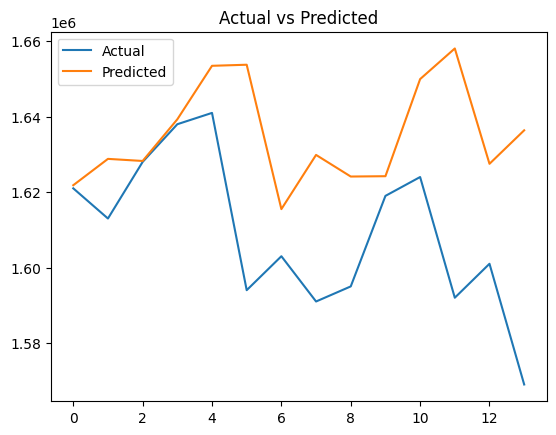

In [13]:
plt.plot(y_test.values, label="Actual")
plt.plot(predict, label="Predicted")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [16]:
mae = mean_absolute_error(y_test, predict)
rmse = np.sqrt(mean_squared_error(y_test, predict))

print("MAE is -",mae)
print("RMSE is -",rmse)

MAE is - 25862.88538890096
RMSE is - 34647.540235321205
